In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/PaddleDet-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/17LXx-YpP2lamkZUgiY1A62xV8O46AQcz/PaddleDet-Models


In [2]:
!python --version

Python 3.12.13


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/train/")
count_images("/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/")

Total images: 642
Total images: 54


In [ ]:
# Check train annotations
with open("/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_train.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_valid.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 642
Train annotations: 657
Categories: [{'id': 1, 'name': 'excavator'}]

Valid images: 54
Valid annotations: 54


In [2]:
!git clone https://github.com/PaddlePaddle/PaddleDetection.git
%cd PaddleDetection

fatal: destination path 'PaddleDetection' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/17LXx-YpP2lamkZUgiY1A62xV8O46AQcz/PaddleDet-Models/PaddleDetection


In [4]:
!pip install paddlepaddle-gpu pyclipper attrdict gdown -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 59.8 MB/s eta 0:00:00


In [ ]:
# Force the "bridge" version of NumPy that works for both Python 3.12 and Paddle
!pip install numpy==1.26.4 --force-reinstall

# Re-install OpenCV without dependencies to stop it from fighting with NumPy
!pip install opencv-python-headless --no-deps --force-reinstall

In [3]:
!pip install -q -e .

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 21.0 MB/s eta 0:00:00


In [4]:
!python -c "import paddle; print(paddle.__version__); print(paddle.device.get_device()); import ppdet; print(ppdet.__version__)"

2.6.2
gpu:0
[05/27 16:50:05] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
0.0.0


In [5]:
!python ppdet/modeling/tests/test_architectures.py

[05/27 16:50:35] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0527 16:50:37.002074  5816 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0527 16:50:37.029939  5816 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
.......
----------------------------------------------------------------------
Ran 7 tests in 10.430s

OK


In [6]:
import json
import os

os.makedirs('dataset/coco/annotations', exist_ok=True)

COCO_CLASSES = ('person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
                'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
                'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
                'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
                'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
                'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
                'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
                'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
                'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
                'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
                'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
                'scissors', 'teddy bear', 'hair drier', 'toothbrush')

categories = []
for i, name in enumerate(COCO_CLASSES):
    categories.append({"id": i, "name": name, "supercategory": "none"})

dummy_data = {
    "images": [],
    "annotations": [],
    "categories": categories
}

with open('dataset/coco/annotations/instances_val2017.json', 'w') as f:
    json.dump(dummy_data, f)

print("Better dummy JSON created! Labels will now show real names.")

Better dummy JSON created! Labels will now show real names.


In [7]:
# !python tools/infer.py --help

In [8]:
!python tools/infer.py \
-c configs/ppyoloe/ppyoloe_plus_crn_s_80e_coco.yml \
-o use_gpu=True \
weights=https://paddledet.bj.bcebos.com/models/ppyoloe_plus_crn_s_80e_coco.pdparams \
--infer_img=/content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/room1.png \
--draw_threshold=0.3

[05/27 16:56:58] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0527 16:57:01.397279  7439 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0527 16:57:01.398491  7439 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/27 16:57:01] ppdet.utils.download INFO: Downloading ppyoloe_plus_crn_s_80e_coco.pdparams from https://paddledet.bj.bcebos.com/models/ppyoloe_plus_crn_s_80e_coco.pdparams
100% 31706/31706 [00:19<00:00, 1597.02KB/s] 
[05/27 16:57:24] ppdet.utils.checkpoint INFO: Finish loading model weights: /root/.cache/paddle/weights/ppyoloe_plus_crn_s_80e_coco.pdparams
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 1/1 [00:03<00:00,  3.02s/it]
[05/27 16:57:30] ppdet.engine INFO: Detection bbox results save in output/room1.png


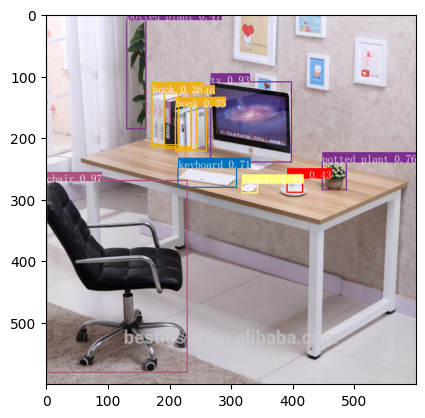

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/room1.png')

plt.figure("Image")
plt.imshow(img)
plt.show()

In [19]:
!ls configs/ppyoloe/

application
_base_
distill
objects365
ppyoloe_crn_l_300e_coco.yml
ppyoloe_crn_l_36e_coco_xpu.yml
ppyoloe_crn_m_300e_coco.yml
ppyoloe_crn_s_300e_coco.yml
ppyoloe_crn_s_400e_coco.yml
ppyoloe_crn_x_300e_coco.yml
ppyoloe_plus_crn_l_80e_coco.yml
ppyoloe_plus_crn_m_80e_coco.yml
ppyoloe_plus_crn_s_80e_coco.yml
ppyoloe_plus_crn_t_auxhead_300e_coco.yml
ppyoloe_plus_crn_t_auxhead_320_300e_coco.yml
ppyoloe_plus_crn_t_auxhead_relu_300e_coco.yml
ppyoloe_plus_crn_t_auxhead_relu_320_300e_coco.yml
ppyoloe_plus_crn_x_80e_coco.yml
ppyoloe_plus_excavators.yml
README_cn.md
README_legacy.md
README.md
voc


In [14]:
642/8

80.25

In [16]:
custom_cfg = """
metric: COCO
num_classes: 1

TrainDataset:
  !COCODataSet
    image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/train/
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_train.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/
    data_fields: ['image', 'gt_bbox', 'gt_class', 'is_crowd']

EvalDataset:
  !COCODataSet
    image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_valid.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

TestDataset:
  !ImageFolder
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_valid.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

worker_num: 8
eval_height: &eval_height 640
eval_width: &eval_width 640
eval_size: &eval_size [*eval_height, *eval_width]

TrainReader:
  sample_transforms:
    - Decode: {}
    - RandomDistort: {}
    - RandomExpand: {fill_value: [123.675, 116.28, 103.53]}
    - RandomCrop: {}
    - RandomFlip: {}
  batch_transforms:
    - BatchRandomResize: {target_size: [320, 352, 384, 416, 448, 480, 512, 544, 576, 608, 640, 672, 704, 736, 768], random_size: True, random_interp: True, keep_ratio: False}
    - NormalizeImage: {mean: [0., 0., 0.], std: [1., 1., 1.], norm_type: none}
    - Permute: {}
    - PadGT: {}
  batch_size: 8
  shuffle: true
  drop_last: true
  use_shared_memory: true
  collate_batch: true

EvalReader:
  sample_transforms:
    - Decode: {}
    - Resize: {target_size: *eval_size, keep_ratio: False, interp: 2}
    - NormalizeImage: {mean: [0., 0., 0.], std: [1., 1., 1.], norm_type: none}
    - Permute: {}
  batch_size: 2

TestReader:
  inputs_def:
    image_shape: [3, *eval_height, *eval_width]
  sample_transforms:
    - Decode: {}
    - Resize: {target_size: *eval_size, keep_ratio: False, interp: 2}
    - NormalizeImage: {mean: [0., 0., 0.], std: [1., 1., 1.], norm_type: none}
    - Permute: {}
  batch_size: 1

architecture: YOLOv3
pretrain_weights: https://paddledet.bj.bcebos.com/models/ppyoloe_plus_crn_s_80e_coco.pdparams
depth_mult: 0.33
width_mult: 0.50

norm_type: sync_bn
use_ema: true
ema_decay: 0.9998
ema_black_list: ['proj_conv.weight']
custom_black_list: ['reduce_mean']

YOLOv3:
  backbone: CSPResNet
  neck: CustomCSPPAN
  yolo_head: PPYOLOEHead
  post_process: ~

CSPResNet:
  layers: [3, 6, 6, 3]
  channels: [64, 128, 256, 512, 1024]
  return_idx: [1, 2, 3]
  use_large_stem: True
  use_alpha: True

CustomCSPPAN:
  out_channels: [768, 384, 192]
  stage_num: 1
  block_num: 3
  act: 'swish'
  spp: true

PPYOLOEHead:
  fpn_strides: [32, 16, 8]
  grid_cell_scale: 5.0
  grid_cell_offset: 0.5
  static_assigner_epoch: 30
  use_varifocal_loss: True
  loss_weight: {class: 1.0, iou: 2.5, dfl: 0.5}
  static_assigner:
    name: ATSSAssigner
    topk: 9
  assigner:
    name: TaskAlignedAssigner
    topk: 13
    alpha: 1.0
    beta: 6.0
  nms:
    name: MultiClassNMS
    nms_top_k: 1000
    keep_top_k: 100
    score_threshold: 0.01
    nms_threshold: 0.7

use_gpu: true
use_xpu: false
log_iter: 5
save_dir: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators
snapshot_epoch: 2
print_flops: false

# Exporting the model
export:
  post_process: True  # Whether post-processing is included in the network when export model.
  nms: True           # Whether NMS is included in the network when export model.
  benchmark: False    # It is used to testing model performance, if set `True`, post-process and NMS will not be exported.
  fuse_conv_bn: False

weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model

epoch: 20
LearningRate:
  base_lr: 0.001
  schedulers:
    - name: CosineDecay
      max_epochs: 20
    - name: LinearWarmup
      start_factor: 0.
      epochs: 4

OptimizerBuilder:
  optimizer:
    momentum: 0.9
    type: Momentum
  regularizer:
    factor: 0.0005
    type: L2
"""

with open('configs/ppyoloe/ppyoloe_plus_excavators.yml', 'w') as f:
    f.write(custom_cfg)

In [21]:
# usage: train.py [-h] [-c CONFIG] [-o [OPT ...]] [--eval] [-r RESUME]
#                 [--slim_config SLIM_CONFIG] [--enable_ce ENABLE_CE] [--amp]
#                 [--fleet] [--use_vdl USE_VDL] [--vdl_log_dir VDL_LOG_DIR]
#                 [--use_wandb USE_WANDB] [--save_prediction_only]
#                 [--profiler_options PROFILER_OPTIONS] [--save_proposals]
#                 [--proposals_path PROPOSALS_PATH] [--to_static]

In [22]:
!python tools/train.py \
-c configs/ppyoloe/ppyoloe_plus_excavators.yml \
-o use_gpu=True \
--eval

[05/27 17:13:13] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
[05/27 17:13:17] ppdet.data.source.coco INFO: Load [642 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_train.json.
W0527 17:13:17.954969 11653 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0527 17:13:17.955894 11653 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/27 17:13:19] ppdet.utils.checkpoint INFO: The shape [80] in pretrained weight yolo_head.pred_cls.0.bias is unmatched with the shape [1] in model yolo_head.pred_cls.0.bias. And the weight yolo_head.pred_cls.0.bias will not be loaded
[05/27 17:13:19] ppdet.utils.checkpoint INFO: The shape [80, 384, 3, 3] in pretrained weight yolo_head.pred_cls.0.weight is unmatched with the shape [1, 384, 3

In [23]:
!python tools/eval.py \
-c configs/ppyoloe/ppyoloe_plus_excavators.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model \
-o use_gpu=True

[05/27 17:40:48] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0527 17:40:48.810385 36028 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0527 17:40:48.811360 36028 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[05/27 17:40:49] ppdet.data.source.coco INFO: Load [54 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/cleaned_detection_annotations_valid.json.
[05/27 17:40:49] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model.pdparams
[05/27 17:40:51] ppdet.engine.callbacks INFO: Eval iter: 0
[05/27 17:40:52] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
loading annotations into memory...
Done (t=0.00s)
creating

In [24]:
!python tools/infer.py \
-c configs/ppyoloe/ppyoloe_plus_excavators.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model \
-o use_gpu=True \
--infer_img=/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/Baidu_0090_jpeg_jpg.rf.62915ac8c1ba10ce731758b70660fece.jpg \
--draw_threshold=0.3

[05/27 17:41:33] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0527 17:41:34.101248 36290 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0527 17:41:34.102166 36290 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/27 17:41:34] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model.pdparams
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
100% 1/1 [00:00<00:00,  1.45it/s]
[05/27 17:41:35] ppdet.engine INFO: Detection bbox results save in output/Baidu_0090_jpeg_jpg.rf.62915ac8c1ba10ce731758b70660fece.jpg


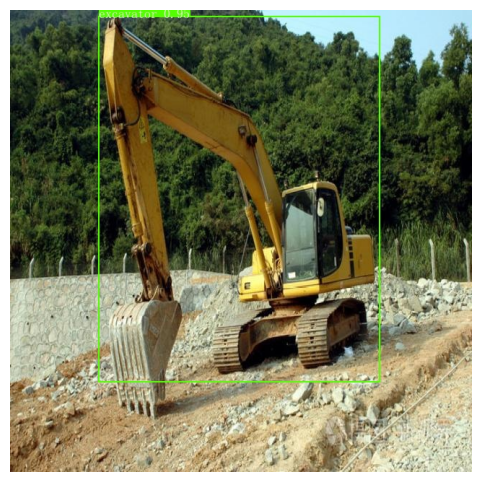

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/Baidu_0090_jpeg_jpg.rf.62915ac8c1ba10ce731758b70660fece.jpg')

plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img)
plt.show()

In [27]:
!python tools/infer.py \
-c configs/ppyoloe/ppyoloe_plus_excavators.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model \
-o use_gpu=True \
--infer_dir=/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/ \
--output_dir=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/infer_images/ \
--draw_threshold=0.3 \
--save_results=True

[05/27 17:43:35] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0527 17:43:35.604260 36848 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0527 17:43:35.605168 36848 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/27 17:43:36] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model.pdparams
[05/27 17:43:36] train INFO: Found 54 inference images in total.
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 54/54 [00:02<00:00, 18.31it/s]
[05/27 17:43:39] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
[05/27 17:43:39] ppdet.metrics.metrics INFO: Th

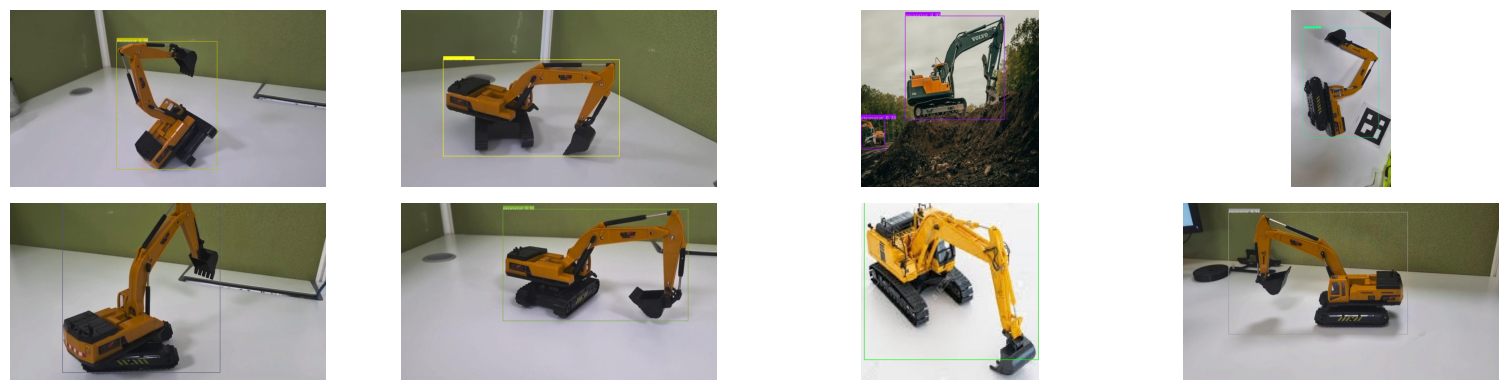

In [30]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import cv2
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/infer_images/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
!python tools/export_model.py \
-c configs/ppyoloe/ppyoloe_plus_excavators.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model

[05/27 17:46:35] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
[05/27 17:46:35] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/best_model.pdparams
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[05/27 17:46:43] ppdet.engine INFO: Export inference config file to output_inference/ppyoloe_plus_excavators/infer_cfg.yml
[05/27 17:46:43] ppdet.engine INFO: Skipping import of the encryption module.
I0527 17:46:44.545663 37675 program_interpreter.cc:212] New Executor is Running.
[05/27 17:46:44] ppdet.engine INFO: Export model and saved in output_inference/ppyoloe_plus_excavators


In [32]:
!pip install onnx onnxscript paddle2onnx==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.9 MB/s eta 0:00:00


In [33]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.0 MB/s eta 0:00:00


In [34]:
!paddle2onnx --model_dir=./output_inference/ppyoloe_plus_excavators/ \
            --model_filename model.pdmodel  \
            --params_filename model.pdiparams \
            --opset_version 11 \
            --save_file /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/ppyoloe_plus_excavators.onnx

[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: ./output_inference/ppyoloe_plus_excavators/model.pdmodel
[Paddle2ONNX] Paramters file path: ./output_inference/ppyoloe_plus_excavators/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[ERROR] Cannot found attribute beta in op: swish


In [35]:
import paddle
from paddle.base import core
import paddle2onnx
import os

model_dir = "./output_inference/ppyoloe_plus_excavators/"
model_file = os.path.join(model_dir, "model.pdmodel")
params_file = os.path.join(model_dir, "model.pdiparams")
fixed_model_file = os.path.join(model_dir, "model_fixed.pdmodel")
save_path = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/ppyoloe_plus_excavators.onnx"

# Ensure the output directory on Google Drive exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# 2. Re-serialize the binary structure to inject the missing beta attribute structure
print("Reading original binary graph configuration...")
with open(model_file, "rb") as f:
    program_desc_str = f.read()

program_desc = core.ProgramDesc(program_desc_str)
patched_count = 0

print("Scanning for 'swish' activation layers...")
for b_idx in range(program_desc.num_blocks()):
    block = program_desc.block(b_idx)
    for o_idx in range(block.op_size()):
        op = block.op(o_idx)
        if op.type() == "swish":
            # Force set the default float value for 'beta' inside the protobuf structure
            op._set_attr("beta", 1.0)
            patched_count += 1

print(f"Injected 'beta' attribute into {patched_count} swish nodes.")

# Save out the corrected model format to a temporary file
with open(fixed_model_file, "wb") as f:
    f.write(program_desc.serialize_to_string())
print(f"Saved layout fixed model description to: {fixed_model_file}")

# 3. Perform the conversion using the correct paddle2onnx.export arguments
print("\nConverting patched model using Paddle2ONNX Python API...")
try:
    paddle2onnx.export(
        model_file=fixed_model_file,
        params_file=params_file,
        save_file=save_path,
        opset_version=11
    )
    print(f"🎉 Success! ONNX model successfully generated and saved to:\n{save_path}")

    # Optional: Clean up the temporary file if everything worked
    if os.path.exists(fixed_model_file):
        os.remove(fixed_model_file)

except Exception as e:
    print(f"❌ Conversion pass failed: {e}")

Reading original binary graph configuration...
Scanning for 'swish' activation layers...
Injected 'beta' attribute into 67 swish nodes.
Saved layout fixed model description to: ./output_inference/ppyoloe_plus_excavators/model_fixed.pdmodel

Converting patched model using Paddle2ONNX Python API...
🎉 Success! ONNX model successfully generated and saved to:
/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/ppyoloe_plus_excavators.onnx


In [38]:
%ls /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/

best_model/       best_model.pdparams  ppyoloe_plus_excavators.onnx
best_model.pdema  best_model.pdstates
best_model.pdopt  infer_images/


In [39]:
!pip install onnx onnx-graphsurgeon --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.6 MB/s eta 0:00:00


In [40]:
import onnx
import onnx_graphsurgeon as gs
import numpy as np

onnx_path = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/ppyoloe_plus_excavators.onnx"

print("Loading clean ONNX model into GraphSurgeon...")
graph = gs.import_onnx(onnx.load(onnx_path))

fixed_count = 0

# Scan for GatherND nodes
for node in graph.nodes:
    if node.op == "GatherND":
        if len(node.inputs) >= 2:
            # Safely grab the original data stream tensor reference
            original_indices_tensor = node.inputs[1]

            # Create a separate, isolated output destination variable for the cast operation
            cast_out_variable = gs.Variable(
                name=f"{original_indices_tensor.name}_safe_cast_i64",
                dtype=np.int64
            )

            # Create the Cast node (to int64 -> attribute 7)
            cast_node = gs.Node(
                op="Cast",
                name=f"p2o.SafeCast.GatherND.{fixed_count}",
                inputs=[original_indices_tensor],
                outputs=[cast_out_variable],
                attrs={"to": 7}
            )

            # Append our cast block into the master execution list
            graph.nodes.append(cast_node)

            # Reassign inputs for GatherND: [Data Tensor (Index 0), New Cast Output Tensor (Index 1)]
            node.inputs = [node.inputs[0], cast_out_variable]
            fixed_count += 1

print(f"Successfully inserted {fixed_count} explicit conversion Cast nodes.")

if fixed_count > 0:
    # Safely repair structural indices and overwrite the file
    graph.cleanup().toposort()
    onnx.save(gs.export_onnx(graph), onnx_path)
    print(f"🎉 Success! Patched model saved to:\n{onnx_path}")
else:
    print("No nodes required updates.")

Loading clean ONNX model into GraphSurgeon...
Successfully inserted 0 explicit conversion Cast nodes.
No nodes required updates.


In [45]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/excavators.jpg"

img = cv2.imread(img_path)
orig_h, orig_w = img.shape[:2] # Get original dimensions
img_resized = cv2.resize(img, (640, 640))
img_input = (img_resized[:, :, ::-1].astype(np.float32)) / 255
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Calculate scale factor
# PaddleDetection ONNX models with post-processing often expect scale_factor as [original_height / target_height, original_width / target_width]
scale_y = orig_h / 640.0
scale_x = orig_w / 640.0
scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

# Calculate im_shape for the model
# Assuming im_shape expects the original image height and width
im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

# Run inference
session = onnxruntime.InferenceSession("/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/ppyoloe_plus_excavators/ppyoloe_plus_excavators.onnx", providers=["CUDAExecutionProvider"])

# Inspect inputs to confirm names and shapes (for debugging)
input_names = [inp.name for inp in session.get_inputs()]
print("Expected input names from ONNX model:", input_names)

# Provide both 'image' and 'scale_factor' as required by the model
input_feed = {
    "image": img_input,
    "scale_factor": scale_factor_input
}

outputs = session.run(None, input_feed)

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Expected input names from ONNX model: ['image', 'scale_factor']
Output: [(74, 6), (1,)]


In [46]:
print(outputs[0])

[[ 0.00000000e+00  9.29650247e-01  5.19709816e+01  3.44034821e-01
   1.66196808e+02  1.20167122e+02]
 [ 0.00000000e+00  9.16539371e-01  1.38149109e+01  1.67066040e+02
   8.91720047e+01  3.05485168e+02]
 [ 0.00000000e+00  2.61977851e-01  5.14315681e+01  2.70272702e-01
   1.67775711e+02  2.51094986e+02]
 [ 0.00000000e+00  1.76787972e-01  5.14560356e+01 -2.90545434e-01
   1.67088760e+02  1.74856934e+02]
 [ 0.00000000e+00  1.04439974e-01  3.59336700e+01 -1.02694595e+00
   1.69684814e+02  3.17838745e+02]
 [ 0.00000000e+00  9.68351364e-02  1.20570068e+01  1.67249527e+02
   1.26224648e+02  3.15787231e+02]
 [ 0.00000000e+00  9.08443928e-02  1.27215424e+01  1.64479294e+02
   9.21189575e+01  3.85435272e+02]
 [ 0.00000000e+00  6.62028193e-02  1.39664965e+01  1.70047958e+02
   6.69178543e+01  3.06852753e+02]
 [ 0.00000000e+00  5.89720607e-02  9.67633057e+00  1.64033630e+02
   1.56766541e+02  3.43658661e+02]
 [ 0.00000000e+00  4.73622680e-02  9.93107128e+00  1.63435837e+02
   1.38819290e+02  4.0426

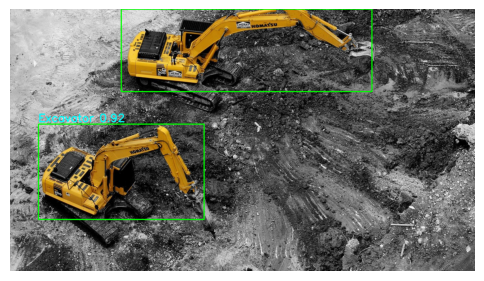

In [47]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASS_LABELS = ["Excavator"]

PRED_COLORS = [
    (0, 255, 0),           # Green
]

# 1. Get original dimensions
orig_h, orig_w = img.shape[:2]
img_with_bbox = img.copy()

# 2. Extract results
# Paddle Output[0] shape is (N, 6) -> [class_id, score, x1, y1, x2, y2]
det_results = outputs[0]

# 3. Filter and Draw
score_thr = 0.5

for res in det_results:
    label_id = int(res[0])
    score = res[1]
    bbox = res[2:] # [x1, y1, x2, y2]

    if score < score_thr:
        continue

    x1, y1, x2, y2 = map(int, bbox)

    # Calculate scale factors
    x1 = int(x1 * orig_w / 640)
    y1 = int(y1 * orig_h / 640)
    x2 = int(x2 * orig_w / 640)
    y2 = int(y2 * orig_h / 640)

    x1 = int(x1 * orig_w / 640)
    y1 = int(y1 * orig_h / 640)
    x2 = int(x2 * orig_w / 640)
    y2 = int(y2 * orig_h / 640)

    label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
    color = PRED_COLORS[label_id]

    # Draw on the ORIGINAL image
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

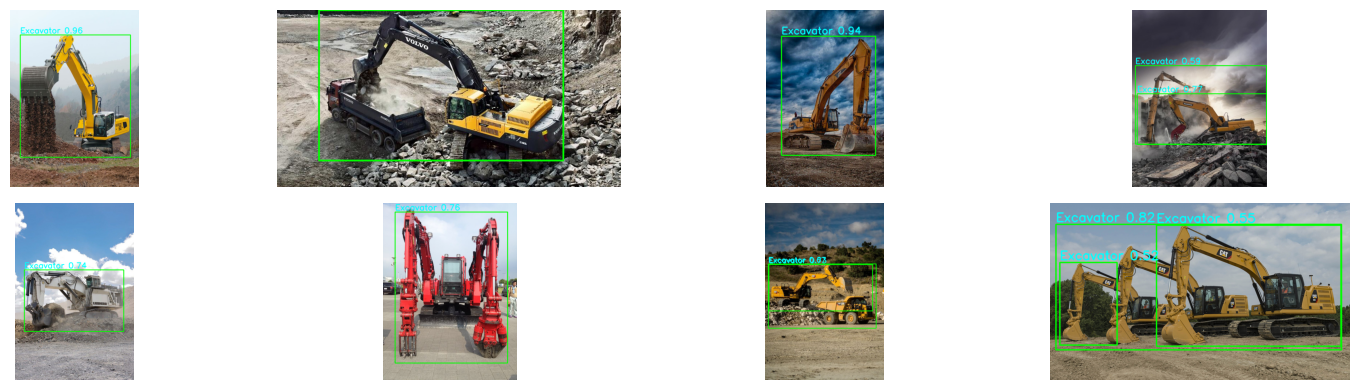

In [50]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/excavators-test"

CLASS_LABELS = ["Excavator"]

PRED_COLORS = [
    (0, 255, 0),           # Green
]

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    orig_h, orig_w = img.shape[:2]
    img_resized = cv2.resize(img, (640, 640))
    img_input = (img_resized[:, :, ::-1].astype(np.float32)) / 255
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    scale_y = orig_h / 640.0
    scale_x = orig_w / 640.0
    scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

    im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

    input_feed = {
        "image": img_input,
        "scale_factor": scale_factor_input
    }

    outputs = session.run(None, input_feed)

    img_with_bbox = img.copy()
    det_results = outputs[0]

    score_thr = 0.5

    for res in det_results:
        label_id = int(res[0])
        score = res[1]
        bbox = res[2:] # [x1, y1, x2, y2]

        if score < score_thr:
            continue

        x1, y1, x2, y2 = map(int, bbox)

        # Calculate scale factors
        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
        color = PRED_COLORS[label_id]

        # Draw on the ORIGINAL image
        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

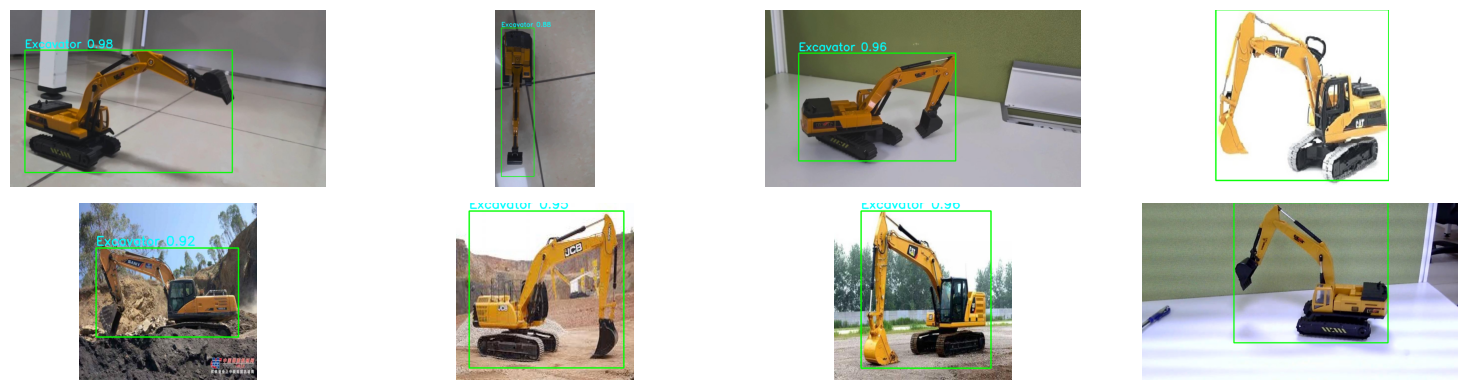

In [51]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid"

CLASS_LABELS = ["Excavator"]

PRED_COLORS = [
    (0, 255, 0),           # Green
]

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    orig_h, orig_w = img.shape[:2]
    img_resized = cv2.resize(img, (640, 640))
    img_input = (img_resized[:, :, ::-1].astype(np.float32)) / 255
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    scale_y = orig_h / 640.0
    scale_x = orig_w / 640.0
    scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

    im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

    input_feed = {
        "image": img_input,
        "scale_factor": scale_factor_input
    }

    outputs = session.run(None, input_feed)

    img_with_bbox = img.copy()
    det_results = outputs[0]

    score_thr = 0.5

    for res in det_results:
        label_id = int(res[0])
        score = res[1]
        bbox = res[2:] # [x1, y1, x2, y2]

        if score < score_thr:
            continue

        x1, y1, x2, y2 = map(int, bbox)

        # Calculate scale factors
        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
        color = PRED_COLORS[label_id]

        # Draw on the ORIGINAL image
        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()